# Моделирование температуры сплава в тигель ковше
Выпускной проект

## Описание
Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Наша задача — построить модель, которая будет её предсказывать. 

## План работы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import optuna

In [2]:
pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")

## Загрузка данных

In [3]:
def load_dataset(name, parse_dates=None, sep=',', decimal='.'):
	df = pd.DataFrame()
	try:
		df = pd.read_csv(f'./datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из локальной папки')
	except:
		df = pd.read_csv(f'https://code.s3.yandex.net/datasets/{name}_new.csv', sep=sep, decimal=decimal, index_col='key', parse_dates=parse_dates)
		print(f'{name} загружен из облака')
	df.sort_index(inplace=True)
	return df

In [4]:
data_arc		= load_dataset('data_arc', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
data_bulk		= load_dataset('data_bulk')
data_bulk_time	= load_dataset('data_bulk_time', parse_dates=list(range(1, data_bulk.shape[1] + 1)))
data_gas		= load_dataset('data_gas')
data_temp		= load_dataset('data_temp', parse_dates=[1])
data_wire		= load_dataset('data_wire')
data_wire_time	= load_dataset('data_wire_time', parse_dates=list(range(1, data_wire.shape[1] + 1)))

data_arc загружен из локальной папки
data_bulk загружен из локальной папки
data_bulk_time загружен из локальной папки
data_gas загружен из локальной папки
data_temp загружен из локальной папки
data_wire загружен из локальной папки
data_wire_time загружен из локальной папки


## Осмотр данных

In [5]:
"""
Рисует гистограмму и ящик с усами для количественных непрерывных признаков
"""
def plot_col(df, col, axs, cat_target):
	ax = sns.histplot(data=df, x=col, hue=cat_target, bins=50, ax=axs[0]);
	ax.set_xlabel(None)
	ax.set_ylabel(col)
	ax = sns.boxplot(data=df, x=col, ax=axs[1]);
	ax.set_yticklabels([])
	ax.set_xlabel(None)

def plot_num_cont(df_raw, cols=None, cat_target=None):
	df = df_raw.reset_index(drop=True)
	if not cols: cols = df.select_dtypes(include='float64').columns
	row_count = len(cols)
	if row_count == 0:
		return
	fig, axs = plt.subplots(row_count, 2)
	fig.set_size_inches(12, 3 * row_count)
	if len(cols) == 1:
		plot_col(df, cols[0], axs, cat_target)
	else:
		row_idx = 0
		for col in cols:
			plot_col(df, col, axs[row_idx], cat_target)
			row_idx += 1

def explore_df(df):
	print('-' * 100)
	print('sample:')
	display(df.sample(5))
	print('-' * 100)
	print('\ninfo:\n')
	df.info()
	print('-' * 100)
	print('\ndescribe:\n')
	display(df.describe())
	print('-' * 100)
	print('\nduplicates:\n')
	print(f'id duplicates: {df.index.duplicated().sum()}, full row duplicates: {df.duplicated().sum()}')
	print('-' * 100)
	print('\nunique keys:\n')
	print(df.index.unique().size)
	plot_num_cont(df)

### data_arc
данные о нагреве электродами

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов

----------------------------------------------------------------------------------------------------
sample:


,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
key,,,,
1600,2019-07-02 12:28:27,2019-07-02 12:29:55,0.262396,0.210873
582,2019-05-25 12:47:21,2019-05-25 12:50:58,0.471106,0.402173
2604,2019-08-14 13:30:43,2019-08-14 13:32:05,1.039328,0.890836
1438,2019-06-26 11:34:04,2019-06-26 11:37:16,0.415213,0.301191
837,2019-06-05 01:52:43,2019-06-05 01:54:59,0.426871,0.291299


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 14876 entries, 1 to 3241
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Начало нагрева дугой  14876 non-null  datetime64[ns]
 1   Конец нагрева дугой   14876 non-null  datetime64[ns]
 2   Активная мощность     14876 non-null  float64       
 3   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2)
memory usage: 581.1 KB
----------------------------------------------------------------------------------------------------

describe:



,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876,14876,14876.000000,14876.000000
mean,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,NaN,NaN,0.258885,5.873485


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 11662, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3214


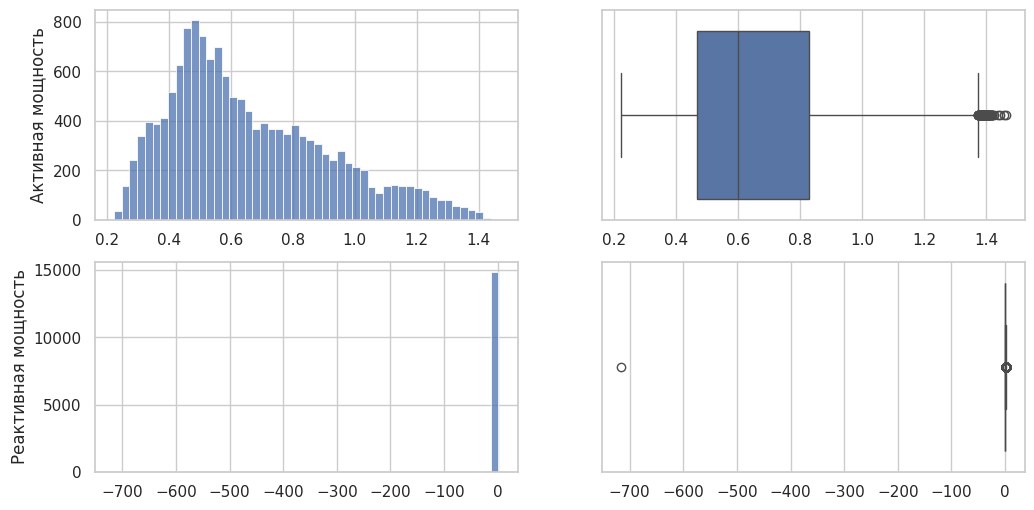

In [6]:
explore_df(data_arc)

- каждая запись - один цикл нагрева ковша с времением начала и конца и параметрами мощности
- по каждому ковшу как правило есть несколько записей - несколько циклов
- аномальный минимум в Реактивной мощности
- пропусков нет
- полных дубликатов нет

### data_bulk
данные о подаче сыпучих материалов (объём)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1407,27.0,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,510.0,NaN,203.0,NaN
850,NaN,NaN,NaN,104.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,199.0,NaN
301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,313.0,NaN,254.0,204.0
3190,NaN,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,208.0,NaN,256.0,108.0
216,NaN,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157.0,NaN,101.0,205.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bulk 1   252 non-null    float64
 1   Bulk 2   22 non-null     float64
 2   Bulk 3   1298 non-null   float64
 3   Bulk 4   1014 non-null   float64
 4   Bulk 5   77 non-null     float64
 5   Bulk 6   576 non-null    float64
 6   Bulk 7   25 non-null     float64
 7   Bulk 8   1 non-null      float64
 8   Bulk 9   19 non-null     float64
 9   Bulk 10  176 non-null    float64
 10  Bulk 11  177 non-null    float64
 11  Bulk 12  2450 non-null   float64
 12  Bulk 13  18 non-null     float64
 13  Bulk 14  2806 non-null   float64
 14  Bulk 15  2248 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB
----------------------------------------------------------------------------------------------------

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 80
----------------------------------------------------------------------------------------------------

unique keys:

3129


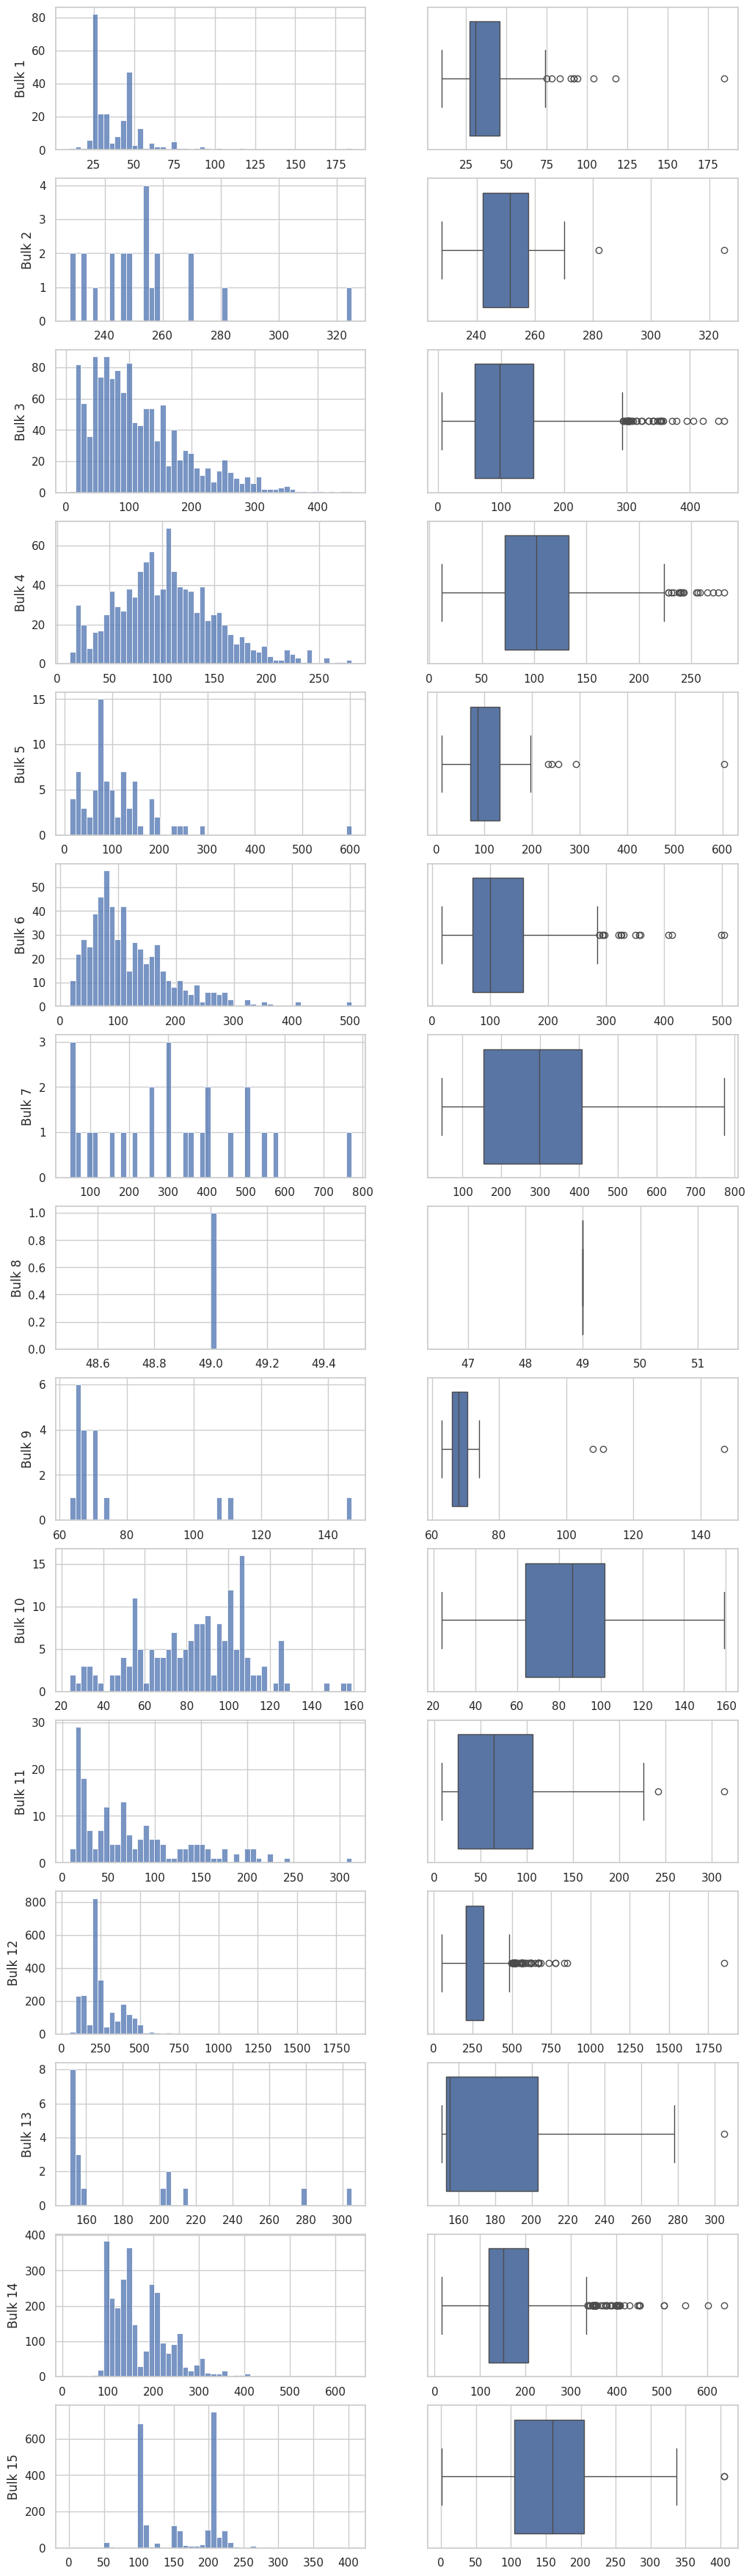

In [7]:
explore_df(data_bulk)

- здесь один ковш - одна запись. колонки по всей видимости соответствуют различным материалам - их поданному в ковш объему
- пропуски видимо значат, что такой материал не применялся, т.е. стоит заменить их на 0
- оценить здесь, что есть выбросы, без дополнительной информации сложно, но явных (отрицательных или огромных, нет)
- дубликатов по ключу нет

### data_bulk_time
данные о подаче сыпучих материалов (время)

In [8]:
explore_df(data_bulk_time)

----------------------------------------------------------------------------------------------------
sample:


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
688,NaT,NaT,2019-05-30 07:51:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-30 07:51:46,NaT,2019-05-30 07:44:56,2019-05-30 07:38:23
1924,NaT,NaT,2019-07-19 13:33:42,NaT,NaT,2019-07-19 14:23:48,NaT,NaT,NaT,NaT,NaT,2019-07-19 14:18:55,NaT,2019-07-19 14:11:47,2019-07-19 13:38:13
2081,NaT,NaT,2019-07-26 08:03:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-07-26 08:00:27,NaT,2019-07-26 07:54:53,NaT
1484,NaT,NaT,2019-06-28 07:49:27,2019-06-28 07:49:27,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-06-28 07:44:07,NaT,2019-06-28 07:40:58,2019-06-28 07:36:30
637,NaT,NaT,2019-05-27 17:24:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-27 17:18:35,NaT,2019-05-27 17:30:07,2019-05-27 17:24:47


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Bulk 1   252 non-null    datetime64[ns]
 1   Bulk 2   22 non-null     datetime64[ns]
 2   Bulk 3   1298 non-null   datetime64[ns]
 3   Bulk 4   1014 non-null   datetime64[ns]
 4   Bulk 5   77 non-null     datetime64[ns]
 5   Bulk 6   576 non-null    datetime64[ns]
 6   Bulk 7   25 non-null     datetime64[ns]
 7   Bulk 8   1 non-null      datetime64[ns]
 8   Bulk 9   19 non-null     datetime64[ns]
 9   Bulk 10  176 non-null    datetime64[ns]
 10  Bulk 11  177 non-null    datetime64[ns]
 11  Bulk 12  2450 non-null   datetime64[ns]
 12  Bulk 13  18 non-null     datetime64[ns]
 13  Bulk 14  2806 non-null   datetime64[ns]
 14  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](1

,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3129


- у data_bulk_time структура такая же, как у data_bulk
- дубликатов по ключу нет

### data_gas
данные о продувке сплава газом

----------------------------------------------------------------------------------------------------
sample:


,Газ 1
key,
2934,22.651157
1176,9.997870
1705,7.856007
2550,8.808677
2079,8.944331


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Газ 1   3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB
----------------------------------------------------------------------------------------------------

describe:



,Газ 1
count,3239.000000
mean,11.002062
std,6.220327
min,0.008399
25%,7.043089
50%,9.836267
75%,13.769915
max,77.995040


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3239


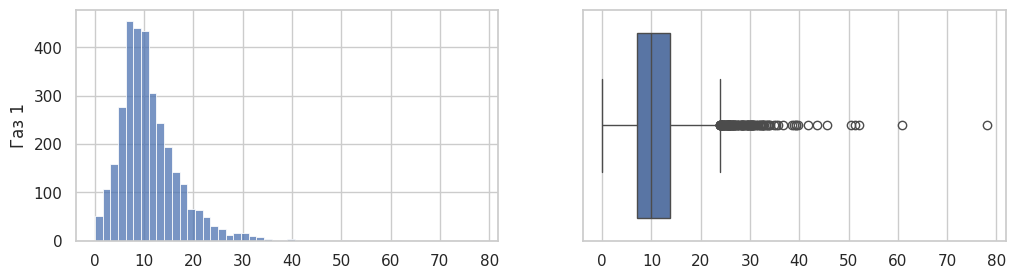

In [9]:
explore_df(data_gas)

- data_gas - просто какой объем газа (видимо, в сумме) был продут через каждый ковш
- дубликатов нет
- лакун нет
- явных выбросов нет

### data_temp
результаты измерения температуры

----------------------------------------------------------------------------------------------------
sample:


,Время замера,Температура
key,,
3030,2019-08-30 11:44:13,NaN
129,2019-05-08 13:26:08,1602.0
461,2019-05-21 03:49:04,1586.0
2809,2019-08-22 05:31:00,NaN
2079,2019-07-26 06:34:04,1598.0


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 18092 entries, 1 to 3241
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Время замера  18092 non-null  datetime64[ns]
 1   Температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 424.0 KB
----------------------------------------------------------------------------------------------------

describe:



,Время замера,Температура
count,18092,14665.000000
mean,2019-07-05 13:36:58.791620608,1590.722741
min,2019-05-03 11:02:04,1191.000000
25%,2019-06-04 00:35:01.249999872,1580.000000
50%,2019-07-03 02:11:48,1590.000000
75%,2019-08-07 23:10:05.249999872,1599.000000
max,2019-09-06 17:30:05,1705.000000
std,NaN,20.394381


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 14876, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3216


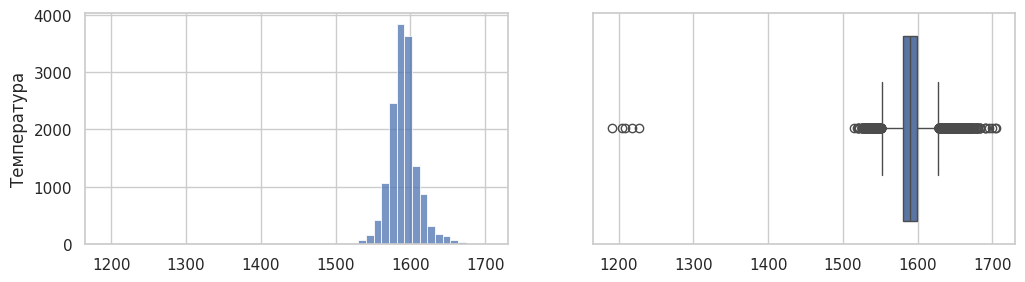

In [10]:
explore_df(data_temp)

- в data_temp каждая запись - один замер (время и температура). как правило по несколько замеров для каждого ковша.
- есть лакуны в поле температуры
- есть значения заведомо ниже температуры плавления сплава (~1400), чего быть не должно - сплав застынет и все - будем считать выбросами
- если не считать выбросы, распределение похоже на нормальное с чуть более вытянутым хвостом в сторону высоких температур

### data_wire
данные о проволочных материалах (объём)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
3029,34.070400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2934,73.207676,25.485201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1861,89.060402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1115,119.386806,20.086559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2056,206.388000,20.719919,NaN,NaN,NaN,NaN,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Wire 1  3055 non-null   float64
 1   Wire 2  1079 non-null   float64
 2   Wire 3  63 non-null     float64
 3   Wire 4  14 non-null     float64
 4   Wire 5  1 non-null      float64
 5   Wire 6  73 non-null     float64
 6   Wire 7  11 non-null     float64
 7   Wire 8  19 non-null     float64
 8   Wire 9  29 non-null     float64
dtypes: float64(9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 403
----------------------------------------------------------------------------------------------------

unique keys:

3081


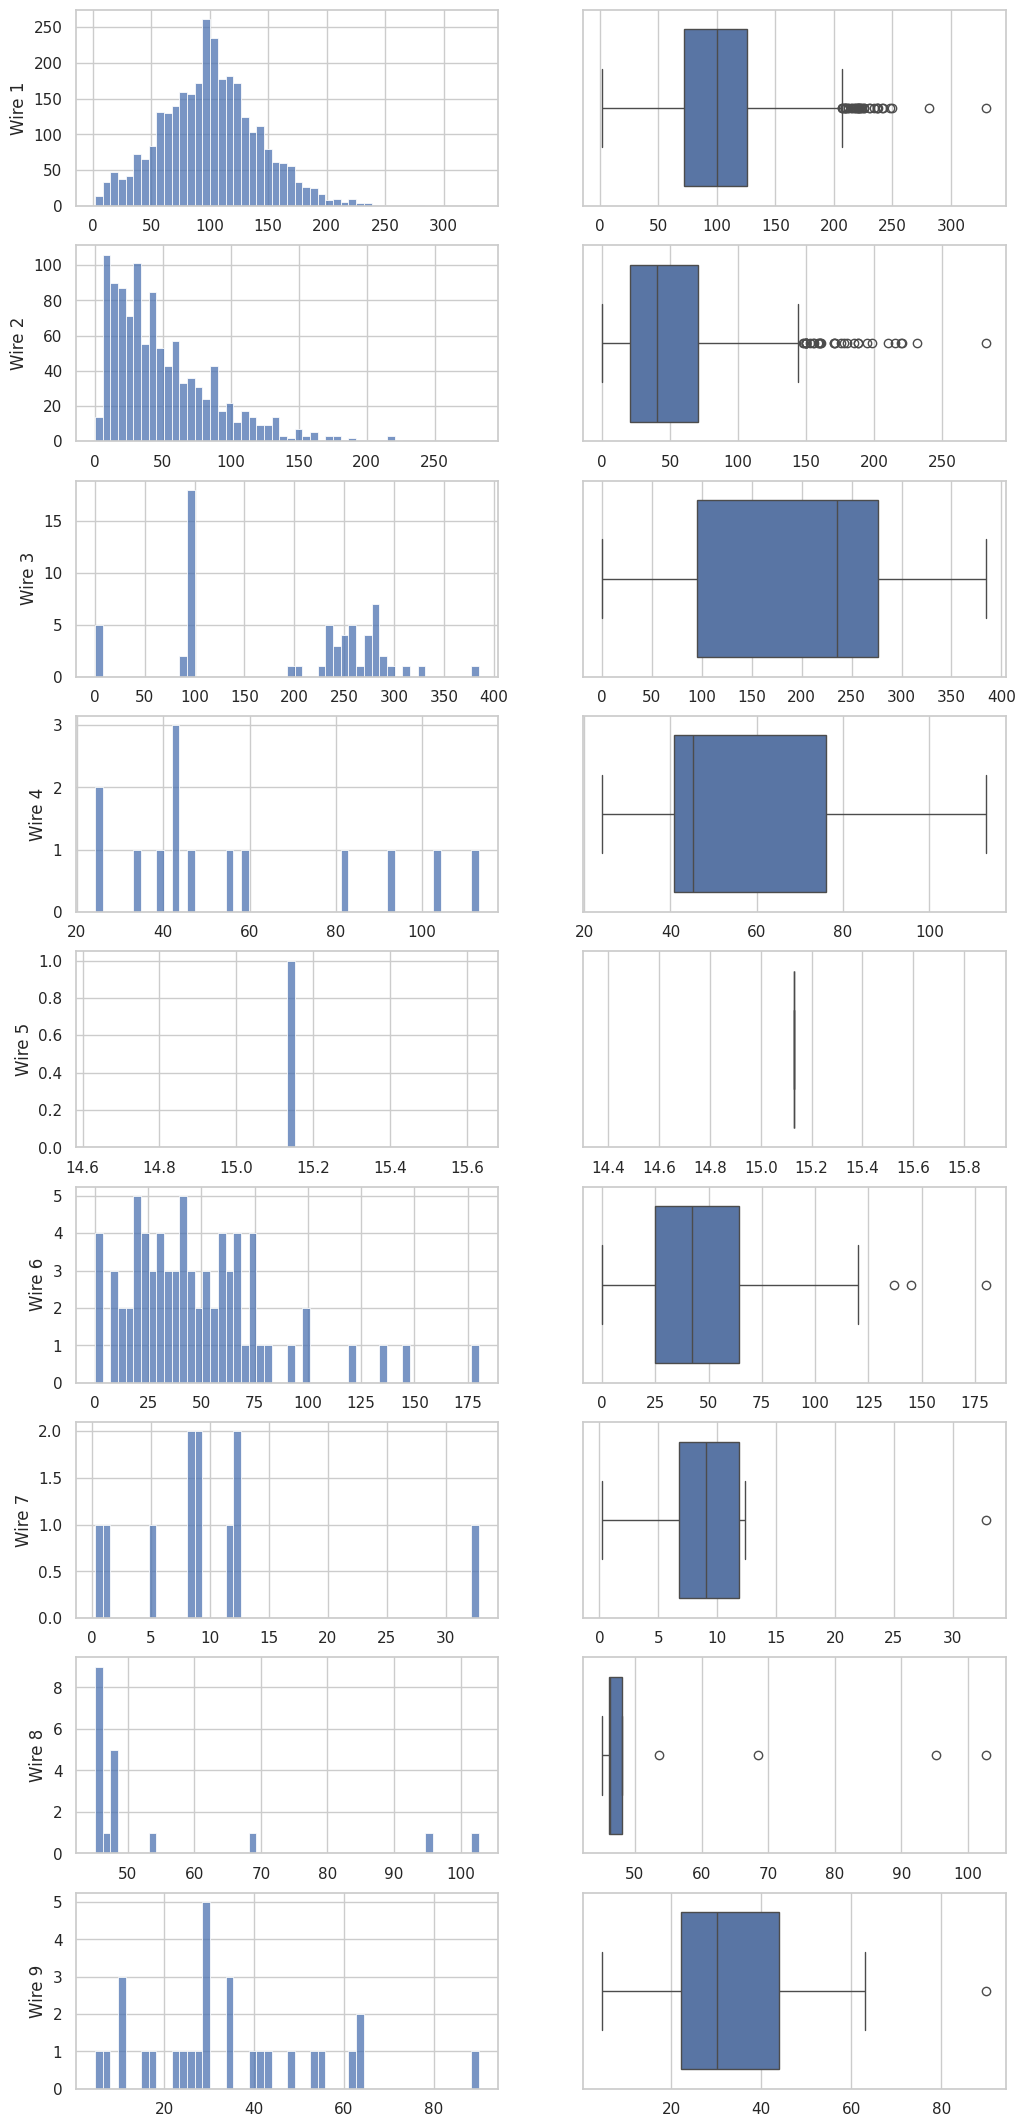

In [11]:
explore_df(data_wire)

- у data_wire такой же принцип структуры, как у bulk
- и так же нет очевидных выбросов
- дубликатов по ключу нет

### data_wire_time
данные о проволочных материалах (время)

In [12]:
explore_df(data_wire_time)

----------------------------------------------------------------------------------------------------
sample:


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
1255,2019-06-19 21:35:27,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1656,2019-07-04 07:01:40,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1851,2019-07-11 02:58:20,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2208,2019-07-31 02:25:50,2019-07-31 02:17:31,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2013,2019-07-24 01:41:27,2019-07-24 01:36:29,NaT,NaT,NaT,NaT,NaT,NaT,NaT


----------------------------------------------------------------------------------------------------

info:

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Wire 1  3055 non-null   datetime64[ns]
 1   Wire 2  1079 non-null   datetime64[ns]
 2   Wire 3  63 non-null     datetime64[ns]
 3   Wire 4  14 non-null     datetime64[ns]
 4   Wire 5  1 non-null      datetime64[ns]
 5   Wire 6  73 non-null     datetime64[ns]
 6   Wire 7  11 non-null     datetime64[ns]
 7   Wire 8  19 non-null     datetime64[ns]
 8   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9)
memory usage: 240.7 KB
----------------------------------------------------------------------------------------------------

describe:



,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3055,1079,63,14,1,73,11,19,29
mean,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23


----------------------------------------------------------------------------------------------------

duplicates:

id duplicates: 0, full row duplicates: 0
----------------------------------------------------------------------------------------------------

unique keys:

3081


- data_wire_time - то же самое, что для data_wire

### Общие выводы по данным
- Есть две очевидные аномалии:
  - очень низкое значение в реактивной мощности
  - есть значения заведомо ниже температуры плавления сплава (~1400)
- Пропуски для bulk и wire надо заменить нулями
- Характер распределений здесь кроме температуры, наверное, описывать смысла нет, т.к. он определяется технологией процесса
- Желательно переименовать колонки в общепринятом стиле
- Хорошо бы найти метод определить время начала работы с ковшом, тогда можно попробовать перевести все времена для ковша в относительные к времени начала
- Для нагрева электродами можно посчитать продолжительность цикла и работу (активная мощность * продолжительность)
- Реактивная мощность по идее не должна влиять на температуру. Только на затраты энергии
- Дубликатов, которые надо убрать, как будто нет

## Предобработка данных
### Переименования колонок

In [13]:
data_arc.columns = ['arc_start_time', 'arc_end_time', 'arc_active_power', 'arc_reactive_power']
data_bulk.columns = [f'bulk_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_bulk_time.columns = [f'bulk_time_{x:02}' for x in range(1, data_bulk.shape[1] + 1)]
data_gas.columns = ['gas_1']
data_temp.columns = ['temp_time', 'temp']
data_wire.columns = [f'wire_{x:02}' for x in range(1, data_wire.shape[1] + 1)]
data_wire_time.columns = [f'wire_time_{x:02}' for x in range(1, data_wire.shape[1] + 1)]

for df in [data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time]:
	print(df.columns)

Index(['arc_start_time', 'arc_end_time', 'arc_active_power',
       'arc_reactive_power'],
      dtype='object')
Index(['bulk_01', 'bulk_02', 'bulk_03', 'bulk_04', 'bulk_05', 'bulk_06',
       'bulk_07', 'bulk_08', 'bulk_09', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')
Index(['bulk_time_01', 'bulk_time_02', 'bulk_time_03', 'bulk_time_04',
       'bulk_time_05', 'bulk_time_06', 'bulk_time_07', 'bulk_time_08',
       'bulk_time_09', 'bulk_time_10', 'bulk_time_11', 'bulk_time_12',
       'bulk_time_13', 'bulk_time_14', 'bulk_time_15'],
      dtype='object')
Index(['gas_1'], dtype='object')
Index(['temp_time', 'temp'], dtype='object')
Index(['wire_01', 'wire_02', 'wire_03', 'wire_04', 'wire_05', 'wire_06',
       'wire_07', 'wire_08', 'wire_09'],
      dtype='object')
Index(['wire_time_01', 'wire_time_02', 'wire_time_03', 'wire_time_04',
       'wire_time_05', 'wire_time_06', 'wire_time_07', 'wire_time_08',
       'wire_time_09'],
      d

### Убираем аномалии
- очень низкое значение в реактивной мощности
- значения заведомо ниже температуры плавления сплава (~1400)

,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power
key,,,,
2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


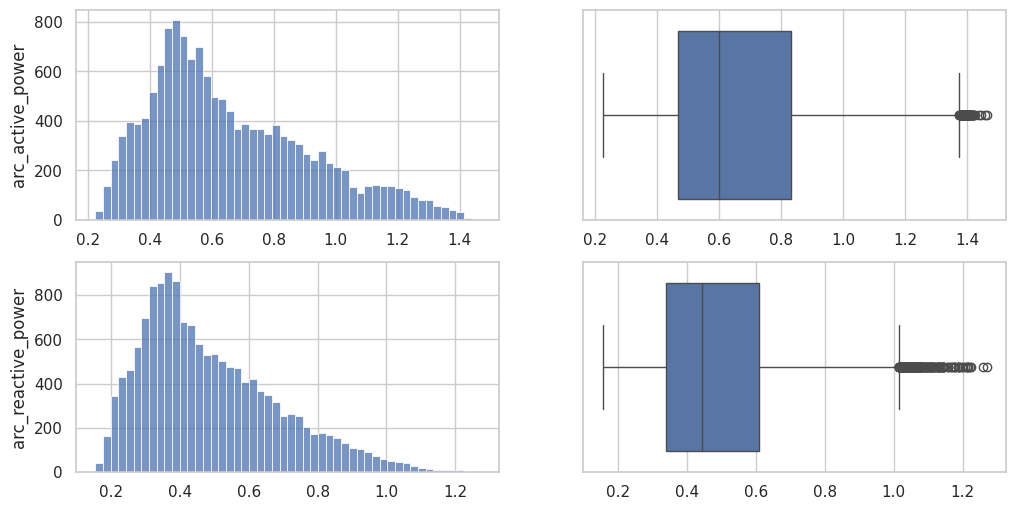

In [14]:
display(data_arc.query('arc_reactive_power < 0'))
data_arc.drop(index=data_arc.query('arc_reactive_power < 0').index, inplace=True)
plot_num_cont(data_arc)

,temp_time,temp
key,,
867,2019-06-06 08:03:39,1191.0
1214,2019-06-18 08:01:03,1208.0
1619,2019-07-03 02:34:41,1218.0
2052,2019-07-25 08:49:15,1227.0
2561,2019-08-12 18:49:29,1204.0


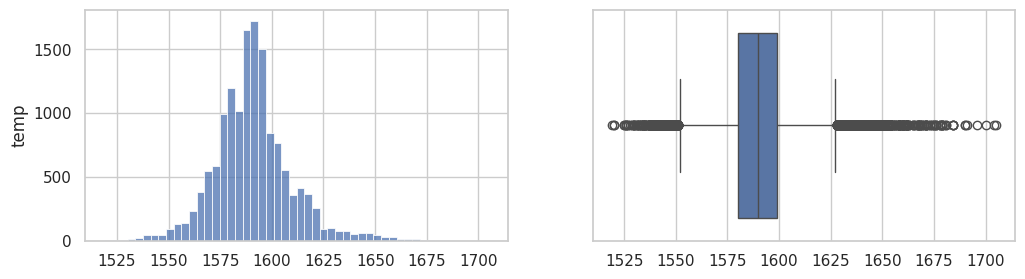

In [15]:
display(data_temp.query('temp < 1400'))
data_temp.drop(index=data_temp.query('temp < 1400').index, inplace=True)
plot_num_cont(data_temp)

### Заменяем пропуски на нули
Там, где это приемлемо: bulk и wire

In [16]:
data_bulk.fillna(value=0, inplace=True)
data_wire.fillna(value=0, inplace=True)
print(data_bulk.isna().sum().sum())
print(data_wire.isna().sum().sum())

0
0


### Удаляем пропуски
В data_temp есть пропуски температуры. Это таргет и измерений для каждого ковша несколько. Наверное, лучше просто удалить пропущенные значения.

In [17]:
data_temp.dropna(inplace=True)
print(data_temp.isna().sum().sum())

0


### Новые признаки в arc
В data_arc надо посчитать работу по нагреву. Т.к. именно от кол-ва джоулей зависит насколько изменится температура.

Для расчета работы возьмем только acive_power, без reacive_power. Т.к."тратится", и соотв. передает энергию только активная составляющая (ну почти только она - реактивная мощность вроде как тоже создает ток, который в среде, обладающей сопротивлением, теряет какую-то часть энергии в тепло, но это не точно).

Длительность нагрева выделим в отдельное поле.

Еще на всякий случай посчитаем полную (кажущуюся) мощность (корень суммы квадратов двух мощностей), и посмотрим, как ее влияение на температуру оценит модель.

In [18]:
data_arc.loc[:, 'arc_duration_sec'] = (data_arc['arc_end_time'] - data_arc['arc_start_time']).dt.seconds
data_arc.loc[:, 'arc_work'] = data_arc['arc_duration_sec'] * data_arc['arc_active_power']
data_arc[['arc_duration_sec', 'arc_active_power', 'arc_work']].sample(3)

,arc_duration_sec,arc_active_power,arc_work
key,,,
1958,111,0.512906,56.932566
3119,270,0.843241,227.675070
2379,225,0.514452,115.751700


In [19]:
data_arc.loc[:, 'arc_apparent_power'] = (data_arc['arc_active_power'] ** 2 + data_arc['arc_reactive_power'] ** 2) ** .5
data_arc['arc_apparent_power'].sample(3)

key
1564    0.647805
803     0.576023
889     1.397546
Name: arc_apparent_power, dtype: float64

### Объединение данных
Попробуем такой подход: у нас для каждого ковша есть несколько измерений температуры в определенные моменты времени и есть данные по действиям, которые совершали над этим ковшом, тоже с указанием моментов времени. Можно сделать такие обучающие записи: предыдущая температура, результирующая температура, все действия, которые были произведены в промежуток времени между этими двумя измерениями температур.

Здесь, правда, есть теоретическая сложность: если время измерения температуры будет попадать в интервал нагрева, то работу по нагреву придется распределять по двум интервалам температур. Но по идее такого быть не должно: нагревали и измеряли, как будто не одновременно. Посмотрим.

Набор со всеми собранными данными будет называться *data_all*

#### Предыдущая температура в том же ковше
Добавим поля temp_time_prev, temp_prev - прошлые измерение температуры в ковше. После этого записи с первыми измерениями удалим.

In [20]:
data_all = data_temp.reset_index().sort_values(by=['key', 'temp_time'])
data_result = pd.DataFrame()
for distance in range(1, 6):
	data_all_prev = data_all.groupby(by='key').shift(periods=distance, fill_value=None)
	data_merged = data_all.merge(data_all_prev, how='left', left_index=True, right_index=True, suffixes=('', '_prev'))
	if data_result.empty:
		data_result = data_merged
	else:
		data_result = pd.concat([data_result, data_merged])

data_all = data_result
data_all.set_index('key', inplace=True)
data_all.sort_values(by=['key', 'temp_time'], inplace=True)
data_all.dropna(inplace=True)

print('before:', data_temp.shape)
display(data_temp.head(15))
print('after:', data_all.shape)
display(data_all.head(15))


before: (14643, 2)


,temp_time,temp
key,,
1,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0
1,2019-05-03 11:30:38,1613.0
2,2019-05-03 11:34:04,1581.0
2,2019-05-03 11:38:40,1577.0
2,2019-05-03 11:46:09,1589.0


after: (33441, 4)


,temp_time,temp,temp_time_prev,temp_prev
key,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:07:18,1604.0
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:02:04,1571.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:18:04,1601.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:11:34,1618.0
1,2019-05-03 11:25:59,1606.0,2019-05-03 11:07:18,1604.0


Добавим поле - временной интервал между измерениями в секундах

In [21]:
data_all.loc[:, 'temp_interval_sec'] = (data_all['temp_time'] - data_all['temp_time_prev']).dt.seconds

#### Таргет - temp_delta
Добавим поле - изменение температуры. Попробуем использовать его как таргет. Идея в том, что модели может быть естественнее посчитать изменение температуры, чем саму ее. (Спойлер - на самом деле как будто все-равно, модели, имея предыдущую температуру, примерно так же справляются с вычислением следующей, как и с дельтой).

In [22]:
data_all.loc[:, 'temp_delta'] = data_all['temp'] - data_all['temp_prev']

#### Добавляем arc
Сначала просто сольем записи все со всеми по номеру ковша

In [23]:
data_all_raw = data_all.merge(data_arc, how='outer', left_index=True, right_index=True, suffixes=('', ''))
data_all_raw

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,189.251040,0.642824
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,128.335684,1.079934
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3241,NaT,NaN,NaT,NaN,NaN,NaN,2019-09-06 16:49:05,2019-09-06 16:51:42,0.439735,0.299579,157.0,69.038395,0.532085
3241,NaT,NaN,NaT,NaN,NaN,NaN,2019-09-06 16:55:11,2019-09-06 16:58:11,0.646498,0.458240,180.0,116.369640,0.792429
3241,NaT,NaN,NaT,NaN,NaN,NaN,2019-09-06 17:06:48,2019-09-06 17:09:52,1.039726,0.769302,184.0,191.309584,1.293389


Теперь оставим только те, где время нагрева попадает в интервал между измерениями температуры, или где не было нагрева

In [24]:
data_all_raw = data_all_raw.query(
	'arc_start_time >= temp_time_prev and arc_start_time <= temp_time or \
	 arc_end_time >= temp_time_prev and arc_end_time <= temp_time or \
	 arc_start_time.isna()'
)
data_all_raw

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,2019-08-10 13:58:58,1603.0,2019-08-10 13:41:34,1604.0,1044.0,-1.0,2019-08-10 13:55:06,2019-08-10 13:56:17,0.296379,0.229071,71.0,21.042909,0.374585
2499,2019-08-10 13:58:58,1603.0,2019-08-10 13:33:21,1569.0,1537.0,34.0,2019-08-10 13:33:31,2019-08-10 13:38:43,0.700677,0.534767,312.0,218.611224,0.881433
2499,2019-08-10 13:58:58,1603.0,2019-08-10 13:33:21,1569.0,1537.0,34.0,2019-08-10 13:41:44,2019-08-10 13:45:09,0.333776,0.269695,205.0,68.424080,0.429117


На всякий случай проверим, как выглядят записи без нагрева

In [25]:
data_all_raw.query('arc_start_time.isna()')

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
2116,2019-07-28 02:13:00,1574.0,2019-07-28 02:07:02,1579.0,358.0,-5.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:21:58,1578.0,2019-07-28 02:13:00,1574.0,538.0,4.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:21:58,1578.0,2019-07-28 02:07:02,1579.0,896.0,-1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:21:58,1578.0,423.0,-3.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:13:00,1574.0,961.0,1.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:29:01,1575.0,2019-07-28 02:07:02,1579.0,1319.0,-4.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:29:01,1575.0,395.0,3.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:21:58,1578.0,818.0,0.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN
2116,2019-07-28 02:35:36,1578.0,2019-07-28 02:13:00,1574.0,1356.0,4.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN


В нескольких случаях не было нагрева и температура росла - так, наверное, может быть, но выглядит странно. Если вспомнить, то мы уже удаляли аномалию мощности из 2116-го ковша. Возможно с ним просто что-то сломалось, лучше его убрать из обучения совсем. 

In [26]:
try:
	data_all_raw = data_all_raw.drop(index=2116)
except:
	pass
data_all_raw.shape

(77312, 13)

Больше интервалов записей без нагрева не осталось

Проверим, есть ли частичные пересечения интервалов между измерениями и интервалов нагрева 

In [27]:
data_all_raw.query('arc_start_time < temp_time_prev or arc_end_time > temp_time').shape[0]

0

Таких нет. Это сильно облегчает задачу

Посмотрим, есть ли несколько циклов нагрева в одном интервале между измерениями температуры 

In [28]:
print((data_all_raw.groupby(by=['key', 'temp_time'])['temp_time'].count() > 1).sum())

8958


Поправка: когда использовали только соседние измерения температуры, таких не было. Так что норм.

Значит temp и arc собрали вместе

In [29]:
data_all = data_all_raw
display(data_all.sample(5))
data_all.shape

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power
key,,,,,,,,,,,,,
931,2019-06-08 15:08:36,1649.0,2019-06-08 14:53:42,1679.0,894.0,-30.0,2019-06-08 15:01:45,2019-06-08 15:03:43,0.484027,0.389891,118.0,57.115186,0.621528
1755,2019-07-07 17:42:59,1581.0,2019-07-07 17:37:11,1583.0,348.0,-2.0,2019-07-07 17:37:21,2019-07-07 17:39:11,0.841243,0.713176,110.0,92.536730,1.102864
2205,2019-07-30 23:37:16,1558.0,2019-07-30 23:07:29,1538.0,1787.0,20.0,2019-07-30 23:12:49,2019-07-30 23:22:35,0.369060,0.251403,586.0,216.269160,0.446552
477,2019-05-21 19:46:51,1589.0,2019-05-21 19:32:14,1591.0,877.0,-2.0,2019-05-21 19:38:59,2019-05-21 19:41:05,0.458873,0.366350,126.0,57.817998,0.587177
875,2019-06-06 13:53:12,1591.0,2019-06-06 13:36:22,1569.0,1010.0,22.0,2019-06-06 13:43:02,2019-06-06 13:47:08,0.500626,0.382084,246.0,123.153996,0.629773


(77312, 13)

#### Добавляем bulk
Сначала просто соберем поля вместе

In [30]:
data_all_raw = data_all.\
	merge(data_bulk, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_bulk_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

<class 'pandas.core.frame.DataFrame'>
Index: 77312 entries, 1 to 2499
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time           77312 non-null  datetime64[ns]
 1   temp                77312 non-null  float64       
 2   temp_time_prev      77312 non-null  datetime64[ns]
 3   temp_prev           77312 non-null  float64       
 4   temp_interval_sec   77312 non-null  float64       
 5   temp_delta          77312 non-null  float64       
 6   arc_start_time      77312 non-null  datetime64[ns]
 7   arc_end_time        77312 non-null  datetime64[ns]
 8   arc_active_power    77312 non-null  float64       
 9   arc_reactive_power  77312 non-null  float64       
 10  arc_duration_sec    77312 non-null  float64       
 11  arc_work            77312 non-null  float64       
 12  arc_apparent_power  77312 non-null  float64       
 13  bulk_01             76265 non-null  float64       
 

None

Теперь почистим те bulk, время внесения которых не попадает в интервал между измерениями температуры (здесь может быть долго)

In [31]:
def maybe_clear_additive(df, row_idx, bulk_num, additive):
	additive_col = f'{additive}_{bulk_num:02}'
	additive_time_col = f'{additive}_time_{bulk_num:02}'
	bulk_time = df.loc[row_idx, additive_time_col]
	if bulk_time < df.loc[row_idx, 'temp_time_prev'] or bulk_time > df.loc[row_idx, 'temp_time']:
		df.loc[row_idx, additive_time_col] = pd.NaT
		df.loc[row_idx, additive_col] = 0

def clear_additives(df, additive, additive_count):
	result_df = df.reset_index()
	for row_idx in result_df.index:
		for bulk_num in range(1, additive_count + 1):
			maybe_clear_additive(result_df, row_idx, bulk_num, additive)
	result_df.set_index('key', drop=True, inplace=True)
	return result_df

data_all = clear_additives(data_all_raw, 'bulk', data_bulk.shape[1])

In [32]:
display(data_all_raw.head(5))
display(data_all.head(5))

,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,206.0,0.0,150.0,154.0,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43


,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,NaT


Похоже, получилось

#### Добавляем wire
По такой же схеме, как bulk

In [33]:
data_all_raw = data_all.\
	merge(data_wire, how='left', left_index=True, right_index=True, suffixes=('', '')).\
	merge(data_wire_time, how='left', left_index=True, right_index=True, suffixes=('', ''))
display(data_all_raw.info())

data_all = clear_additives(data_all_raw, 'wire', data_wire.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 77312 entries, 1 to 2499
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   temp_time           77312 non-null  datetime64[ns]
 1   temp                77312 non-null  float64       
 2   temp_time_prev      77312 non-null  datetime64[ns]
 3   temp_prev           77312 non-null  float64       
 4   temp_interval_sec   77312 non-null  float64       
 5   temp_delta          77312 non-null  float64       
 6   arc_start_time      77312 non-null  datetime64[ns]
 7   arc_end_time        77312 non-null  datetime64[ns]
 8   arc_active_power    77312 non-null  float64       
 9   arc_reactive_power  77312 non-null  float64       
 10  arc_duration_sec    77312 non-null  float64       
 11  arc_work            77312 non-null  float64       
 12  arc_apparent_power  77312 non-null  float64       
 13  bulk_01             76265 non-null  float64       
 

None

In [34]:
print(data_all.shape)
display(data_all.head(10))

(77312, 61)


,temp_time,temp,temp_time_prev,temp_prev,temp_interval_sec,temp_delta,arc_start_time,arc_end_time,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_08,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,bulk_time_01,bulk_time_02,bulk_time_03,bulk_time_04,bulk_time_05,bulk_time_06,bulk_time_07,bulk_time_08,bulk_time_09,bulk_time_10,bulk_time_11,bulk_time_12,bulk_time_13,bulk_time_14,bulk_time_15,wire_01,wire_02,wire_03,wire_04,wire_05,wire_06,wire_07,wire_08,wire_09,wire_time_01,wire_time_02,wire_time_03,wire_time_04,wire_time_05,wire_time_06,wire_time_07,wire_time_08,wire_time_09
key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2019-05-03 11:07:18,1604.0,2019-05-03 11:02:04,1571.0,314.0,33.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:07:18,1604.0,256.0,14.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:11:34,1618.0,2019-05-03 11:02:04,1571.0,570.0,47.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:10:43,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:11:34,1618.0,390.0,-17.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,NaT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:07:18,1604.0,646.0,-3.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:07:18,1604.0,646.0,-3.0,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,99.813836,0.722536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:02:04,1571.0,960.0,30.0,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,69.569640,0.371123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,60.059998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2019-05-03 11:18:04,1601.0,2019-05-03 11:02:04,1571.0,960.0,30.0,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,141.646730,0.902319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,154.0,NaT,NaT,N

#### Добавляем gas
Здесь простой мерж

In [60]:
data_gas.head()

,gas_1
key,
1,29.749986
2,12.555561
3,28.554793
4,18.841219
5,5.413692


In [36]:
data_all = data_all.merge(data_gas, how='inner', left_index=True, right_index=True, suffixes=('', ''))

In [37]:
data_all.shape

(77242, 62)

#### Только ключи, которые есть во всех таблицах
У нас есть условие: использовать только те ключи, которые есть во всех таблицах. Т.е. надо проверить, не осталось ли после мержа лакун, допустим, в arc_active_power, bulk_01, wire_01, gas

In [38]:
fields_to_check = ['arc_active_power', 'bulk_01', 'wire_01', 'gas_1']
for fld in fields_to_check:
	print(f'nans in {fld}: {data_all[fld].isna().sum()}')


nans in arc_active_power: 0
nans in bulk_01: 1047
nans in wire_01: 1901
nans in gas_1: 0


Оказывается, есть. Не все ключи из temp были в bulk и wire. Уберем те, которых не было.

In [39]:
keys_to_drop = data_all.query('bulk_01.isna() or wire_01.isna()').index
print('keys to drop:', keys_to_drop)
data_all.drop(index=keys_to_drop, inplace=True)
data_all.shape

keys to drop: Index([  51,   51,   51,   51,   51,   51,   51,   51,   51,   51,
       ...
       2471, 2471, 2471, 2471, 2471, 2471, 2471, 2471, 2471, 2471],
      dtype='int64', name='key', length=2484)


(74758, 62)

#### Убираем все времена
Мы расставили все события по времени, теперь поля со всеми временами можно убрать

In [40]:
data_all_times = data_all
data_all.drop(columns=data_all.select_dtypes(include='datetime64[ns]').columns, inplace=True)

- Как будто на этом объединение, группировка данных и создание фич закончено

## Исследовательский анализ объединённого датафрейма
Временно заменим все нули на nan. Так будет лучше видно ненулевые значения

In [41]:
data_all_nans = data_all.replace(0., np.nan)

In [42]:
display(data_all_nans.info())

<class 'pandas.core.frame.DataFrame'>
Index: 74758 entries, 1 to 2499
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp                74758 non-null  float64
 1   temp_prev           74758 non-null  float64
 2   temp_interval_sec   74758 non-null  float64
 3   temp_delta          71679 non-null  float64
 4   arc_active_power    74758 non-null  float64
 5   arc_reactive_power  74758 non-null  float64
 6   arc_duration_sec    74758 non-null  float64
 7   arc_work            74758 non-null  float64
 8   arc_apparent_power  74758 non-null  float64
 9   bulk_01             3052 non-null   float64
 10  bulk_02             291 non-null    float64
 11  bulk_03             12960 non-null  float64
 12  bulk_04             11046 non-null  float64
 13  bulk_05             1160 non-null   float64
 14  bulk_06             6903 non-null   float64
 15  bulk_07             438 non-null    float64
 16  bulk_08   

None

wire_05 оказался пустым, а у bulk_08 очень мало значений. уберем

In [43]:
try:
	data_all_nans.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

try:
	data_all.drop(columns=['bulk_08', 'wire_05'], inplace=True)
except:
	pass

In [44]:
display(data_all_nans.describe())

,temp,temp_prev,temp_interval_sec,temp_delta,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
count,74758.000000,74758.000000,74758.000000,71679.000000,74758.000000,74758.000000,74758.000000,74758.000000,74758.000000,3052.000000,291.000000,12960.000000,11046.000000,1160.000000,6903.000000,438.000000,266.000000,2146.000000,2358.000000,33598.000000,461.000000,45504.000000,39902.000000,42856.000000,12738.000000,963.000000,345.000000,672.000000,100.000000,225.000000,313.000000,74758.000000
mean,1591.307124,1587.102410,1528.499893,4.385329,0.667612,0.491426,178.830078,119.694228,0.829859,40.514744,261.312715,116.369367,107.813688,114.731034,124.687672,433.742009,76.954887,82.705033,81.552163,285.803679,180.854664,183.520130,165.632475,106.979703,55.699147,182.263636,65.532560,50.646569,2.643623,57.054549,28.993589,13.140213
std,13.613527,19.114018,1195.733717,16.201845,0.261389,0.199793,102.189154,87.134678,0.326773,18.968918,26.371912,78.388521,50.500847,70.051824,76.614428,187.106963,20.997346,28.508538,63.438568,143.544022,51.611662,68.532526,49.753991,44.487163,44.204200,103.893208,29.888379,36.807587,2.886039,20.728832,14.754048,7.716709
min,1525.000000,1519.000000,79.000000,-104.000000,0.223895,0.153777,11.000000,5.246505,0.275718,10.000000,228.000000,6.000000,13.000000,11.000000,17.000000,75.000000,63.000000,24.000000,8.000000,53.000000,151.000000,29.000000,1.000000,1.918800,0.030160,0.144144,24.148801,0.137280,0.234208,45.076721,4.622800,0.008399
25%,1583.000000,1575.000000,820.000000,-4.000000,0.469415,0.339866,109.000000,58.936828,0.581381,27.000000,242.000000,60.000000,73.000000,72.000000,72.000000,306.000000,66.000000,58.000000,25.000000,205.000000,154.000000,129.000000,105.000000,76.096802,23.012081,93.165077,40.069122,18.086641,1.053936,46.002319,17.035200,8.320681
50%,1591.000000,1587.000000,1327.000000,4.000000,0.604079,0.445341,156.000000,97.752116,0.753275,31.000000,249.000000,96.000000,105.000000,103.000000,105.000000,406.000000,68.000000,85.000000,64.000000,230.000000,155.000000,181.000000,200.000000,104.270401,43.128799,231.110901,58.046562,42.076324,1.053936,46.187439,30.066399,11.591509
75%,1599.000000,1599.000000,1927.000000,13.000000,0.836028,0.615680,232.000000,153.692028,1.042378,47.250000,282.000000,154.000000,138.000000,148.000000,162.500000,553.000000,71.000000,105.000000,128.000000,409.000000,159.000000,221.000000,205.000000,134.175598,75.400001,276.324066,92.570401,68.434087,5.035472,46.279999,35.053200,16.137625
max,1662.000000,1662.000000,19454.000000,100.000000,1.463773,1.270284,907.000000,885.343872,1.898158,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000,330.314424,282.780152,385.008668,113.231044,180.454575,8.490040,102.762401,62.025600,77.995040


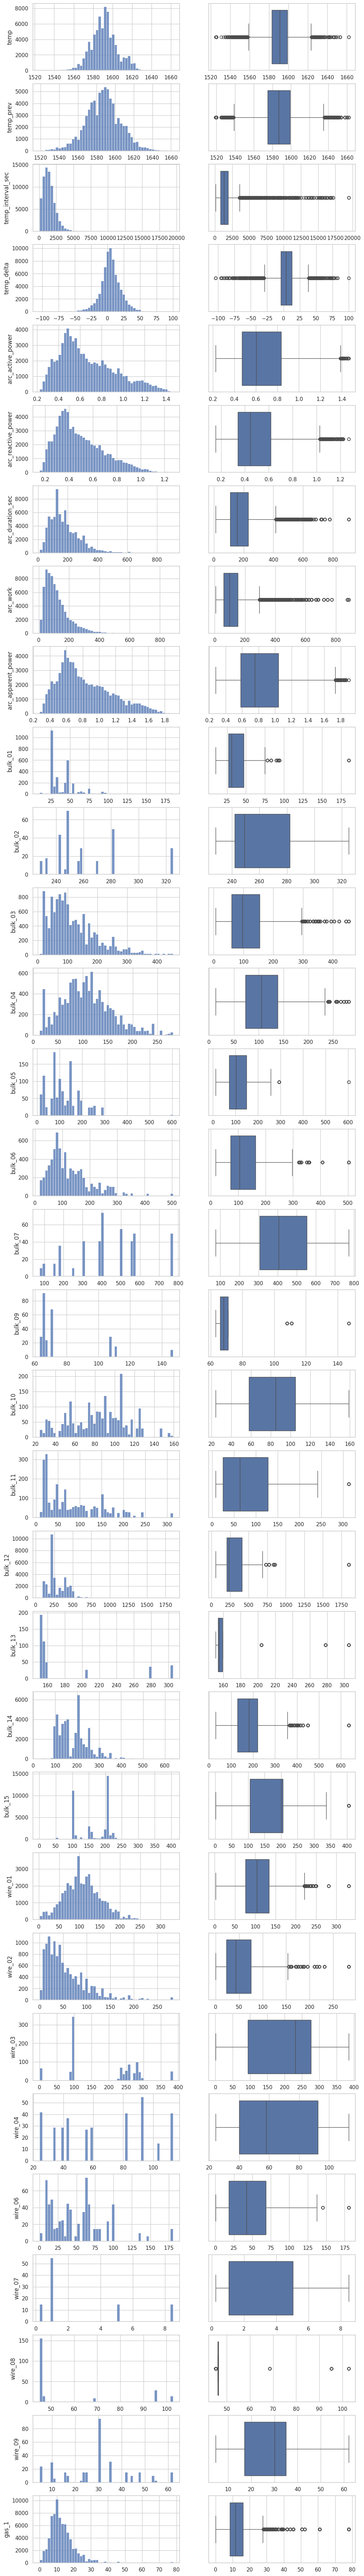

In [45]:
plot_num_cont(data_all_nans)

- Распределение температуры выглядит как нормальное
- Распределение изменения температуры - тоже, с модой чуть выше нуля
- Остальные параметры - artificial, явных выбросов больше не наблюдается
- Порядки значений сильно разнятся, нормализация будет необходима.

### Корреляция между признаками

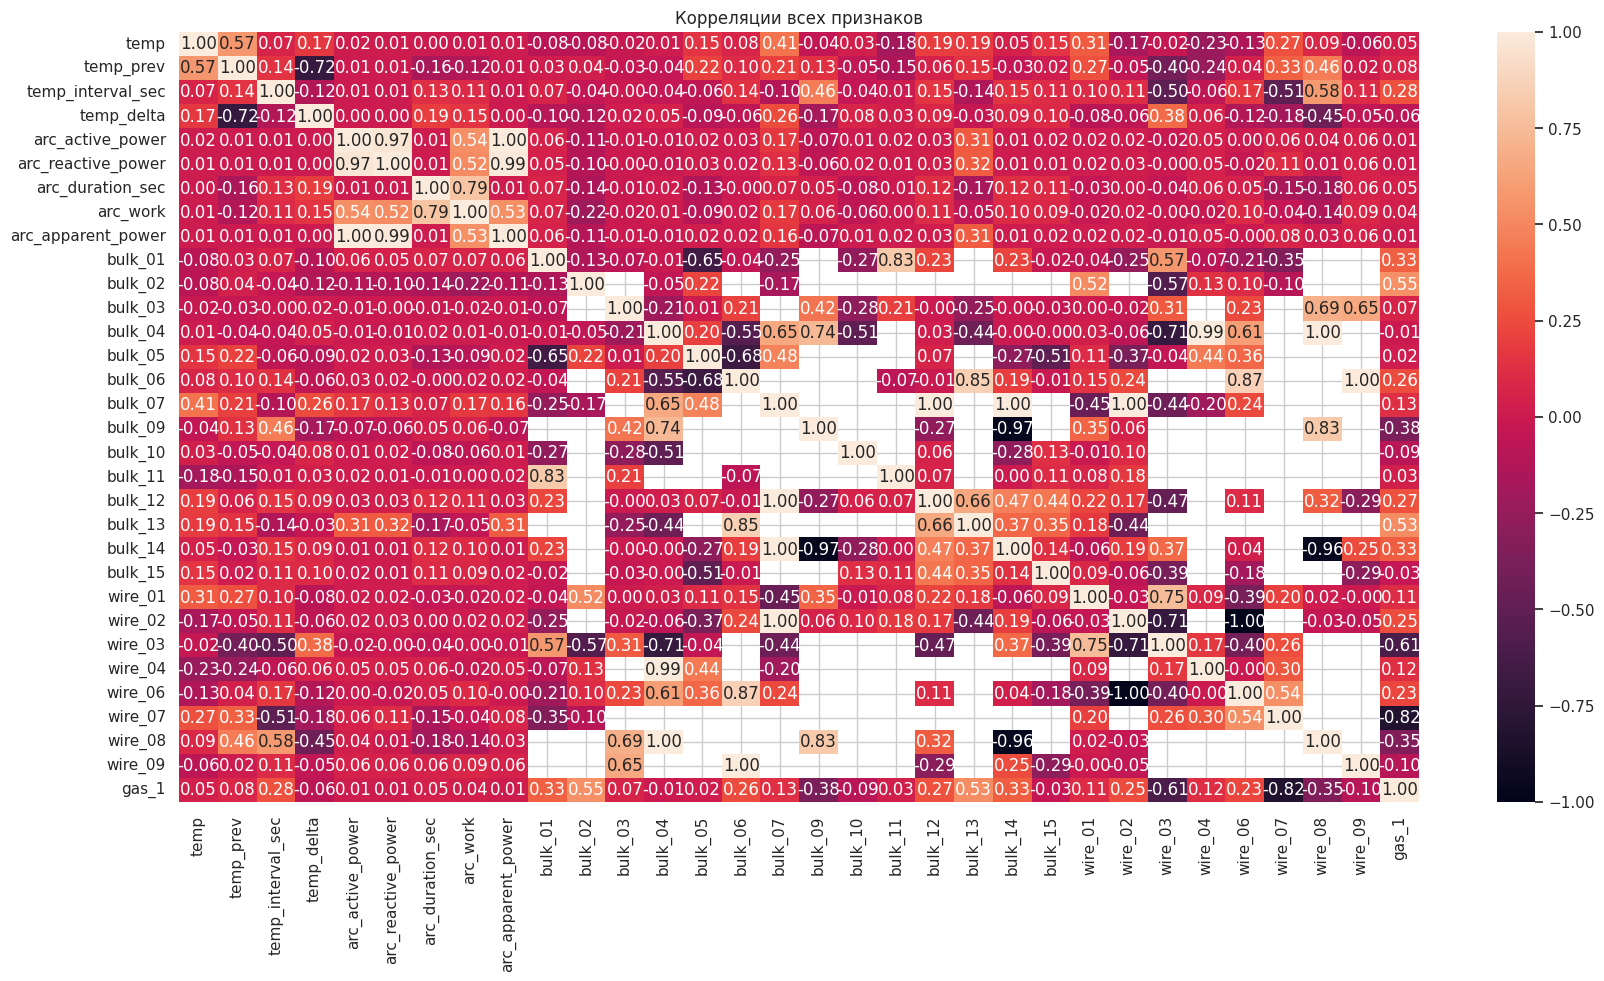

In [61]:
num_col_list = data_all_nans.select_dtypes(include='number').columns.to_list()
corr_matrix = data_all_nans[num_col_list].corr()
plt.figure(figsize=(20, 10))
plot = sns.heatmap(corr_matrix, annot=True, fmt='.2f');
plot.set_title('Корреляции всех признаков');

- Нет каких-то параметров, сильно коррелирующих с температурой.
- По нескольким параметрам наблюдается мультиколлинеарность. Есть смысл убрать из них те, в которых больше всего пропусков.

ищем корреляции больше 0.9

In [47]:
corr_matrix[corr_matrix[corr_matrix > 0.9].count() > 1][corr_matrix > 0.9]

,temp,temp_prev,temp_interval_sec,temp_delta,arc_active_power,arc_reactive_power,arc_duration_sec,arc_work,arc_apparent_power,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_07,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_04,wire_06,wire_07,wire_08,wire_09,gas_1
arc_active_power,NaN,NaN,NaN,NaN,1.000000,0.966747,NaN,NaN,0.995567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arc_reactive_power,NaN,NaN,NaN,NaN,0.966747,1.000000,NaN,NaN,0.986499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arc_apparent_power,NaN,NaN,NaN,NaN,0.995567,0.986499,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.993869,NaN,NaN,1.0,NaN,NaN
bulk_06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
bulk_07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bulk_14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wire_02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wire_04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.993869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN


Еще раз выведем info data_all_nans, чтобы удобнее было выбирать параметры для удаления

In [48]:
data_all_nans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74758 entries, 1 to 2499
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp                74758 non-null  float64
 1   temp_prev           74758 non-null  float64
 2   temp_interval_sec   74758 non-null  float64
 3   temp_delta          71679 non-null  float64
 4   arc_active_power    74758 non-null  float64
 5   arc_reactive_power  74758 non-null  float64
 6   arc_duration_sec    74758 non-null  float64
 7   arc_work            74758 non-null  float64
 8   arc_apparent_power  74758 non-null  float64
 9   bulk_01             3052 non-null   float64
 10  bulk_02             291 non-null    float64
 11  bulk_03             12960 non-null  float64
 12  bulk_04             11046 non-null  float64
 13  bulk_05             1160 non-null   float64
 14  bulk_06             6903 non-null   float64
 15  bulk_07             438 non-null    float64
 16  bulk_09   

flds_to_drop - список параметров, которые удалим перед обучением

In [49]:
flds_to_drop = []
# arc_active_power vs arc_reactive_power
flds_to_drop.append('arc_reactive_power')
# arc_active_power vs arc_apparent_power
flds_to_drop.append('arc_apparent_power')
# bulk_04 (11046) vs wire_04 (345) and wire_08 (225)
flds_to_drop.append('wire_04')
flds_to_drop.append('wire_08')
# bulk_06 (6903) vs wire_09 (313)
flds_to_drop.append('wire_09')
# bulk_07 (438) vs bulk_12 (33598) and bulk_14 (45504) and wire_02 (12738)
flds_to_drop.append('bulk_07')
# wire_09 (313) vs bulk_06 (6903)
flds_to_drop.append('wire_09')
flds_to_drop

['arc_reactive_power',
 'arc_apparent_power',
 'wire_04',
 'wire_08',
 'wire_09',
 'bulk_07',
 'wire_09']

## Обучение
Сделаем класс для удобства изучения моделей. Он поделит выборку на обучающую и тестовую, будет создавать и обучать модели нескольких типов и отображать анализ результатов на обучающей и тестовой выборке.

Сделать reset_index понадобилось для дальнейшего сопоставления спрогнозированных значений и исходных данных.

PolynomialFeatures добавит нелинейности

In [ ]:
class Learn:
	rnd_seed_		= 61026
	test_fraction_	= 0.25
	target_fld_		= 'temp_delta'
	drop_fld_		= ['temp', 'temp_delta'] + flds_to_drop

	def __init__(self, df):
		df_wt_key = df.reset_index(drop=True)
		x = df_wt_key.drop(columns=Learn.drop_fld_)
		y = df_wt_key[Learn.target_fld_]
		self.x_train_, self.x_test_, self.y_train_, self.y_test_ =\
			train_test_split(x, y, test_size=Learn.test_fraction_, random_state=Learn.rnd_seed_)
		self.pipe_lin_reg_ = None
		self.pipe_cat_boost_ = None
		self.pipe_tree_ = None
		self.gradient_boost_ = None

	def linear_regression(self):
		if self.pipe_lin_reg_ is None:
			self.pipe_lin_reg_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						LinearRegression(),
						{},
						cv=5,
						random_state=Learn.rnd_seed_,
						n_trials=1
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_lin_reg_

	def cat_boost(self):
		if self.pipe_cat_boost_ is None:
			self.pipe_cat_boost_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						CatBoostRegressor(
							loss_function='MAE',
							random_seed=Learn.rnd_seed_
						),
						{},
						cv=5,
						random_state=Learn.rnd_seed_,
						n_trials=1
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_cat_boost_

	def decision_tree(self):
		if self.pipe_tree_ is None:
			self.pipe_tree_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					optuna.integration.OptunaSearchCV(
						DecisionTreeRegressor(random_state=Learn.rnd_seed_),
						{
							'max_depth': optuna.distributions.IntDistribution(1, 20, step=1)
						},
						cv=5,
						random_state=Learn.rnd_seed_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.pipe_tree_

	def gradient_boost(self):
		if self.gradient_boost_ is None:
			self.gradient_boost_ = Pipeline([
				('scaler', StandardScaler()),
				('poly', PolynomialFeatures(degree=2)),
				(
					'estimator',
					GradientBoostingRegressor(
						loss='absolute_error',
						random_state=Learn.rnd_seed_
					)
				)
			]).fit(self.x_train_, self.y_train_)
		return self.gradient_boost_

	def explore(self, estimator, x, y, label):
		print(f'{label} R2: {estimator.score(x, y):.04f}')
		y_pred = estimator.predict(x)
		print(f'{label} MAE: {mean_absolute_error(y, y_pred):.04f}')
		y_df = pd.DataFrame({'y_true': y, 'y_pred': y_pred})
		y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']

		fig, axs = plt.subplots(2, 2, figsize=(15, 10))
		sns.scatterplot(y_df, x='y_true', y='y_pred', ax=axs[0, 0]).set_title(f'{label}. Предсказания в пространстве таргета');
		sns.scatterplot(y_df, x='y_true', y='y_error', ax=axs[0, 1]).set_title(f'{label}. Ошибки в пространстве таргета');
		sns.histplot(y_df, x='y_error', ax=axs[1, 0]).set_title(f'{label}. Гистограмма ошибок');
		sns.boxplot(y_df, x='y_error', ax=axs[1, 1]).set_title(f'{label}. Ящик ошибок');

	def explore_train(self, estimator, label):
		self.explore(estimator, self.x_train_, self.y_train_, label + '.train')

	def explore_test(self, estimator, label):
		self.explore(estimator, self.x_test_, self.y_test_, label + '.test')

learn = Learn(data_all)

/tmp/ipykernel_1800901/2054992604.py:25: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-13 05:07:48,255] A new study created in memory with name: no-name-c0397e42-195e-4b01-bc12-7b74a0b3eb47


[I 2025-10-13 05:07:57,190] Trial 0 finished with value: 0.6055705622830013 and parameters: {}. Best is trial 0 with value: 0.6055705622830013.


LinearRegression.train R2: 0.6117
LinearRegression.train MAE: 7.4683


/tmp/ipykernel_1800901/2054992604.py:43: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-13 05:07:59,671] A new study created in memory with name: no-name-5fd35879-e075-44f9-af69-add42b8f2f22


0:	learn: 11.2857789	total: 77.2ms	remaining: 1m 17s
1:	learn: 11.1393240	total: 105ms	remaining: 52.2s
2:	learn: 10.9903437	total: 132ms	remaining: 43.8s
3:	learn: 10.8520601	total: 161ms	remaining: 40s
4:	learn: 10.7175495	total: 188ms	remaining: 37.5s
5:	learn: 10.5919451	total: 215ms	remaining: 35.7s
6:	learn: 10.4740944	total: 244ms	remaining: 34.6s
7:	learn: 10.3580420	total: 271ms	remaining: 33.6s
8:	learn: 10.2481745	total: 299ms	remaining: 32.9s
9:	learn: 10.1435575	total: 328ms	remaining: 32.5s
10:	learn: 10.0416653	total: 355ms	remaining: 32s
11:	learn: 9.9473210	total: 383ms	remaining: 31.6s
12:	learn: 9.8605536	total: 411ms	remaining: 31.2s
13:	learn: 9.7643754	total: 438ms	remaining: 30.8s
14:	learn: 9.6797605	total: 464ms	remaining: 30.5s
15:	learn: 9.5974380	total: 493ms	remaining: 30.3s
16:	learn: 9.5158354	total: 521ms	remaining: 30.1s
17:	learn: 9.4431350	total: 550ms	remaining: 30s
18:	learn: 9.3713526	total: 577ms	remaining: 29.8s
19:	learn: 9.2989686	total: 605ms	

[I 2025-10-13 05:11:49,398] Trial 0 finished with value: 0.6806284704340917 and parameters: {}. Best is trial 0 with value: 0.6806284704340917.


0:	learn: 11.3239586	total: 32.7ms	remaining: 32.6s
1:	learn: 11.1711683	total: 63.6ms	remaining: 31.7s
2:	learn: 11.0236153	total: 94.2ms	remaining: 31.3s
3:	learn: 10.8895687	total: 125ms	remaining: 31.1s
4:	learn: 10.7530088	total: 156ms	remaining: 31s
5:	learn: 10.6258545	total: 185ms	remaining: 30.6s
6:	learn: 10.5034950	total: 215ms	remaining: 30.5s
7:	learn: 10.3869896	total: 246ms	remaining: 30.5s
8:	learn: 10.2724940	total: 277ms	remaining: 30.5s
9:	learn: 10.1657315	total: 307ms	remaining: 30.4s
10:	learn: 10.0662049	total: 338ms	remaining: 30.4s
11:	learn: 9.9658236	total: 367ms	remaining: 30.2s
12:	learn: 9.8787185	total: 397ms	remaining: 30.2s
13:	learn: 9.7837276	total: 427ms	remaining: 30.1s
14:	learn: 9.6943893	total: 458ms	remaining: 30.1s
15:	learn: 9.6128151	total: 488ms	remaining: 30s
16:	learn: 9.5306735	total: 521ms	remaining: 30.1s
17:	learn: 9.4493285	total: 554ms	remaining: 30.2s
18:	learn: 9.3798787	total: 587ms	remaining: 30.3s
19:	learn: 9.3060994	total: 617

/tmp/ipykernel_1800901/2054992604.py:64: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna.integration.OptunaSearchCV(
[I 2025-10-13 05:12:50,318] A new study created in memory with name: no-name-07a4af95-e1c8-4307-a263-3b4c19b90429
[I 2025-10-13 05:12:56,901] Trial 0 finished with value: 0.433276997576124 and parameters: {'max_depth': 2}. Best is trial 0 with value: 0.433276997576124.
[I 2025-10-13 05:13:40,789] Trial 1 finished with value: 0.7170932923029053 and parameters: {'max_depth': 17}. Best is trial 1 with value: 0.7170932923029053.
[I 2025-10-13 05:14:06,850] Trial 2 finished with value: 0.6261264180342911 and parameters: {'max_depth': 9}. Best is trial 1 with value: 0.7170932923029053.
[I 2025-10-13 05:14:10,335] Trial 3 finished with value: 0.28020225251135916 and parameters: {'max_depth': 1}. Best is trial 1 with value: 0.7170932923029053.
[I 2025-10-13 05:14:44,082] Trial 4 finished with value: 0

DecisionTreeRegressor.train R2: 0.8787
DecisionTreeRegressor.train MAE: 3.4025
GradientBoostingRegressor.train R2: 0.6264
GradientBoostingRegressor.train MAE: 7.0957


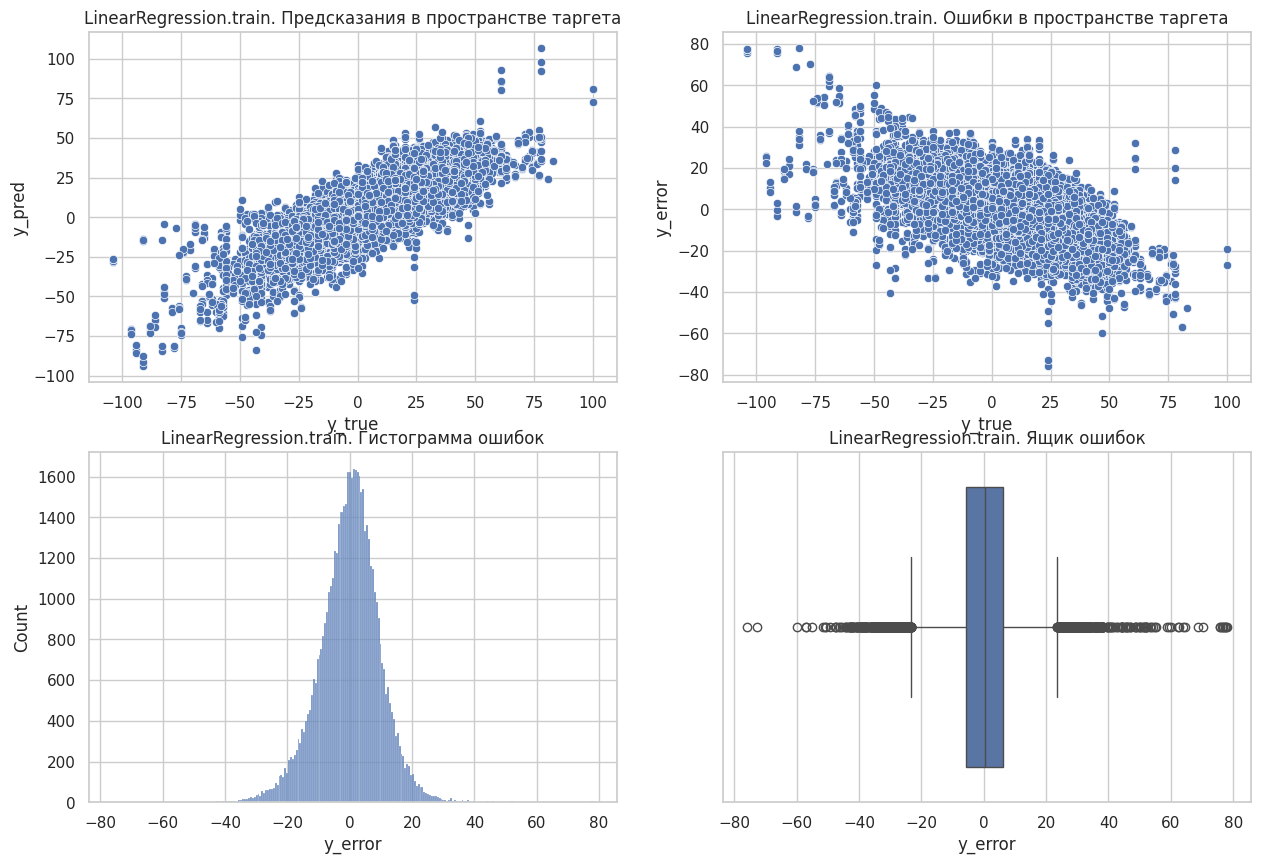

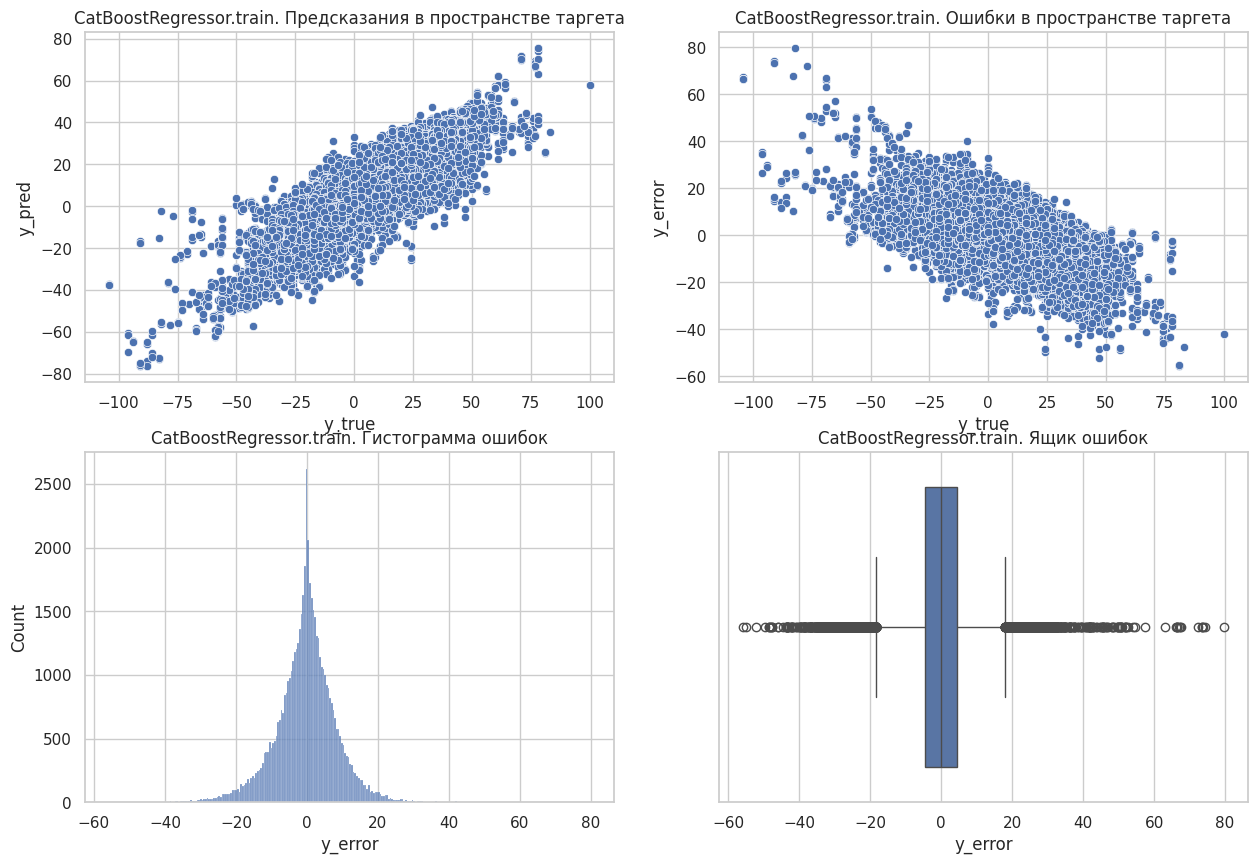

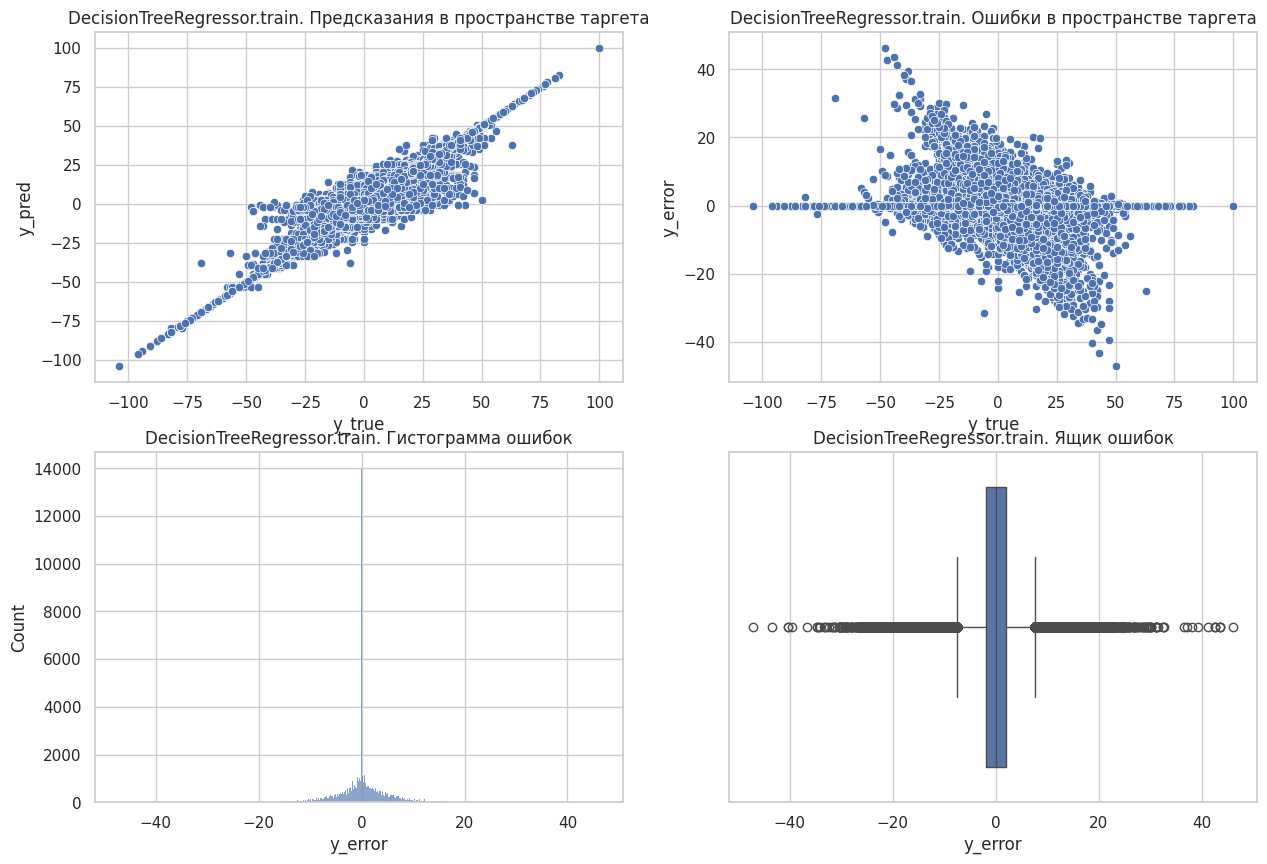

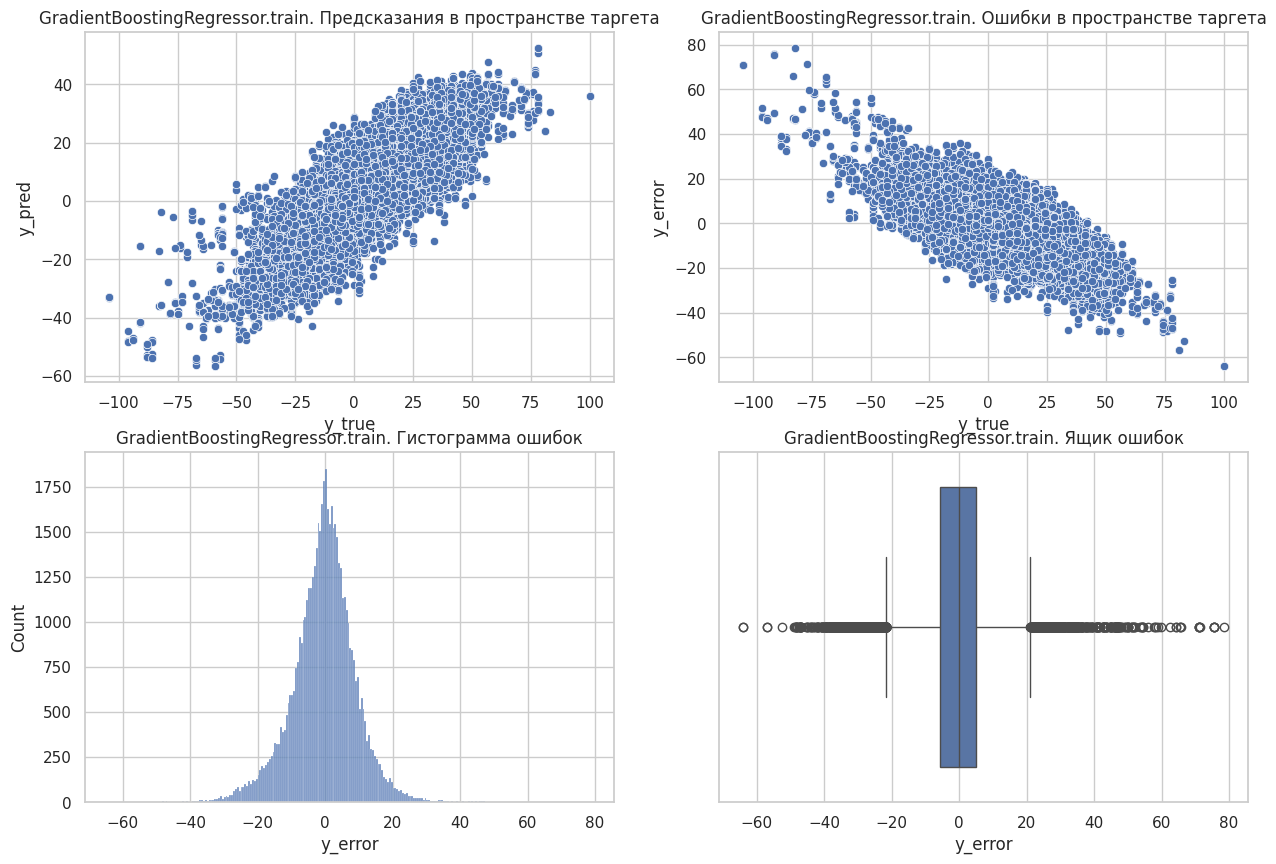

In [51]:
learn.explore_train(learn.linear_regression(), 'LinearRegression')
learn.explore_train(learn.cat_boost(), 'CatBoostRegressor')
learn.explore_train(learn.decision_tree(), 'DecisionTreeRegressor')
learn.explore_train(learn.gradient_boost(), 'GradientBoostingRegressor')


- Облака предсказаний выглядят ожидаемо. Кроме DecisionTreeRegressor - у него есть линия точных попаданий.
- У разброса ошибок есть наклон вниз - при повышении температуры ошибки меньше, чем при понижении.
- Гистограммы ошибок хорошие. Симметричны относительно нуля, выглядят как нормальное распределение.

In [52]:
data_all['temp_delta'].describe()

count    74758.000000
mean         4.204714
std         15.888603
min       -104.000000
25%         -4.000000
50%          4.000000
75%         13.000000
max        100.000000
Name: temp_delta, dtype: float64

- У нас IQR таргета 17 градусов С - это чтобы лучше представлять масштаб ошибки (3-7 град)
- DecisionTreeRegressor сильно выделяется по точности. И часть прогнозов прямо подозрительно точны. Хорошо бы понять, почему, и нет ли где-то ошибки.

Посмотрим, каких значения были у входных параметров там, где ошибка DecisionTreeRegressor близка к 0. Может, там все 0 или какие-то аномалии?

In [53]:
y_df = pd.DataFrame({'y_true': learn.y_train_, 'y_pred': learn.decision_tree().predict(learn.x_train_)})
y_df.loc[:, 'y_error'] = y_df['y_pred'] - y_df['y_true']
y_df = y_df.merge(learn.x_train_, left_index=True, right_index=True, how='inner')
y_df.query('abs(y_error) < 0.1')

,y_true,y_pred,y_error,temp_prev,temp_interval_sec,arc_active_power,arc_duration_sec,arc_work,bulk_01,bulk_02,bulk_03,bulk_04,bulk_05,bulk_06,bulk_09,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,wire_01,wire_02,wire_03,wire_06,wire_07,gas_1
17177,23.0,23.0,0.0,1568.0,786.0,0.281762,149.0,41.982538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,224.0,0.0,136.0,224.0,124.253997,0.000000,0.0,0.0,0.0,6.696740
24605,12.0,12.0,0.0,1573.0,1890.0,0.778034,137.0,106.590658,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,153.0,0.0,153.0,154.0,193.377594,0.000000,0.0,0.0,0.0,17.293232
19690,16.0,16.0,0.0,1565.0,2769.0,0.455800,260.0,118.508000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,393.0,0.0,213.0,188.0,123.130799,0.000000,0.0,0.0,0.0,9.909262
73548,20.0,20.0,0.0,1577.0,1099.0,0.401085,71.0,28.477035,0.0,0.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,361.0,0.0,235.0,0.0,0.000000,0.000000,0.0,0.0,0.0,11.059257
43917,-10.0,-10.0,0.0,1631.0,2683.0,0.647044,152.0,98.350688,0.0,0.0,71.0,199.0,0.0,0.0,0.0,0.0,0.0,412.0,0.0,201.0,205.0,0.000000,0.000000,0.0,0.0,0.0,11.615588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29582,21.0,21.0,0.0,1576.0,287.0,1.013087,214.0,216.800618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,103.0,0.000000,0.000000,0.0,0.0,0.0,10.671592
71153,4.0,4.0,0.0,1562.0,1804.0,0.367869,135.0,49.662315,0.0,0.0,43.0,0.0,0.0,23.0,0.0,0.0,0.0,105.0,0.0,110.0,0.0,0.000000,0.000000,0.0,0.0,0.0,16.309071
6022,-17.0,-17.0,0.0,1603.0,1709.0,0.798544,140.0,111.796160,0.0,0.0,0.0,0.0,0.0,178.0,0.0,0.0,0.0,305.0,0.0,160.0,203.0,121.211998,18.170881,0.0,0.0,0.0,7.972122
41919,2.0,2.0,0.0,1563.0,1109.0,0.831907,254.0,211.304378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,205.0,204.0,135.064804,0.000000,0.0,0.0,0.0,10.655252


- вроде бы нет. ничего в глаза не бросается

Подсмотрим результаты тестовой выборки для нее. Может, там все значительно хуже:

DecisionTreeRegressor.test R2: 0.7597
DecisionTreeRegressor.test MAE: 4.9022


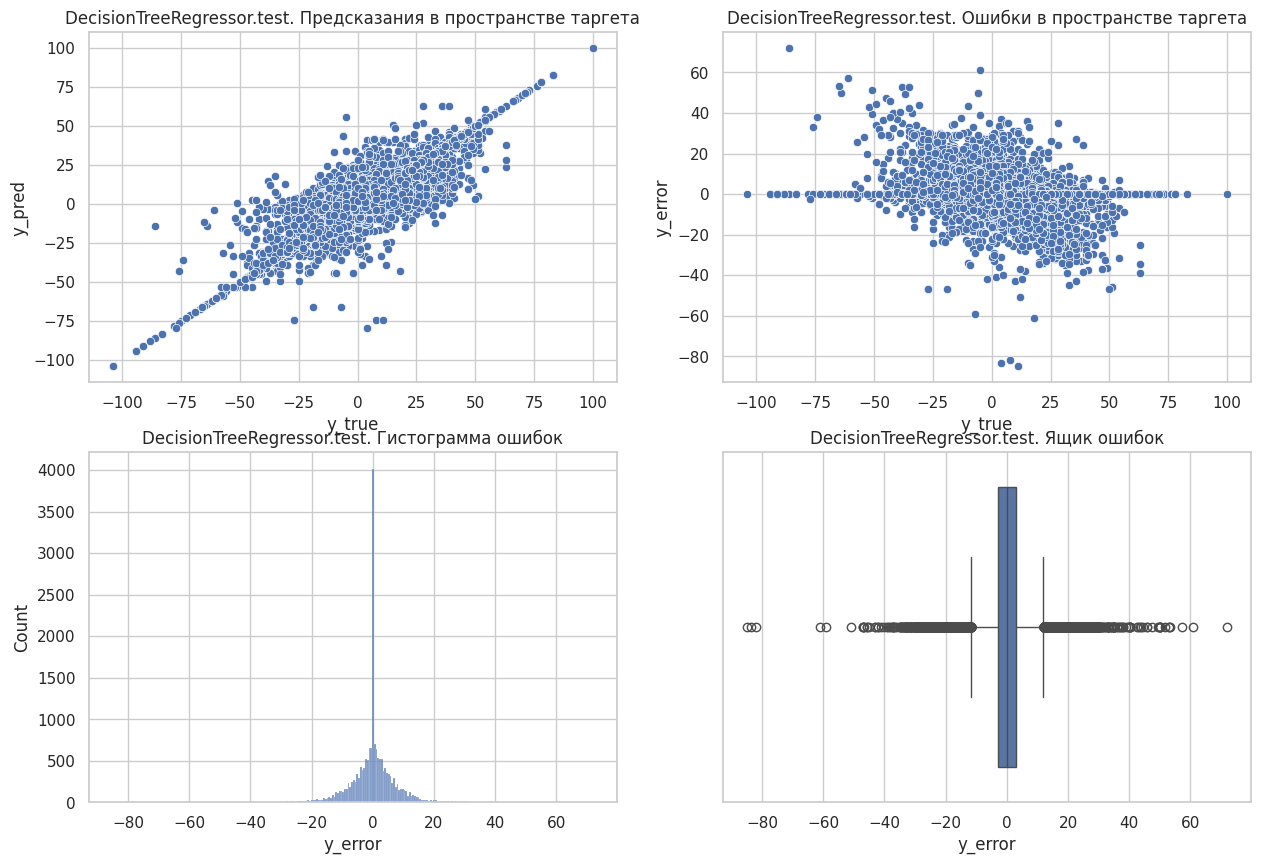

In [54]:
learn.explore_test(learn.decision_tree(), 'DecisionTreeRegressor')

- тоже неплохо относительно остальных. хм

Подсмотрим параметры кэтбуста, чтобы сориентироваться, в каких границах их тюнить.

Key CatBoostRegressor parameters to fine-tune include iterations,
- learning_rate = 0.03 - Used for reducing the gradient step
- depth = 6 - Depth of the trees
- l2_leaf_reg = 3 - Coefficient at the L2 regularization term of the cost function
- subsample = 0.8 - Sample rate for bagging
- rsm = 1 - Random subspace method. The percentage of features to use at each split selection, when features are selected over again at random
- border_count = 254 - The number of splits for numerical features. Allowed values are integers from 1 to 65535 inclusively

 Tuning these values helps optimize the model's performance by adjusting the number of trees, the step size of each tree, the complexity of the trees, and how features are sampled during training.

In [55]:
learn.cat_boost().named_steps['estimator'].best_estimator_.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'MAE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Exact',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'random_seed': 61026,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'MAE',
 'lea

## Важность признаков

Собираем вместе имена признаков и значения их важности

Для наглядности отсечем только самые важные. Статистика поможет выбрать порог

In [63]:
feature_importances = pd.DataFrame(
	{
		'name': learn.decision_tree().named_steps['poly'].get_feature_names_out(input_features=learn.x_train_.columns),
		'importance': learn.decision_tree().named_steps['estimator'].best_estimator_.feature_importances_
	}
)
feature_importances.describe()

,importance
count,325.000000
mean,0.003077
std,0.023427
min,0.000000
25%,0.000060
50%,0.000455
75%,0.001859
max,0.412437


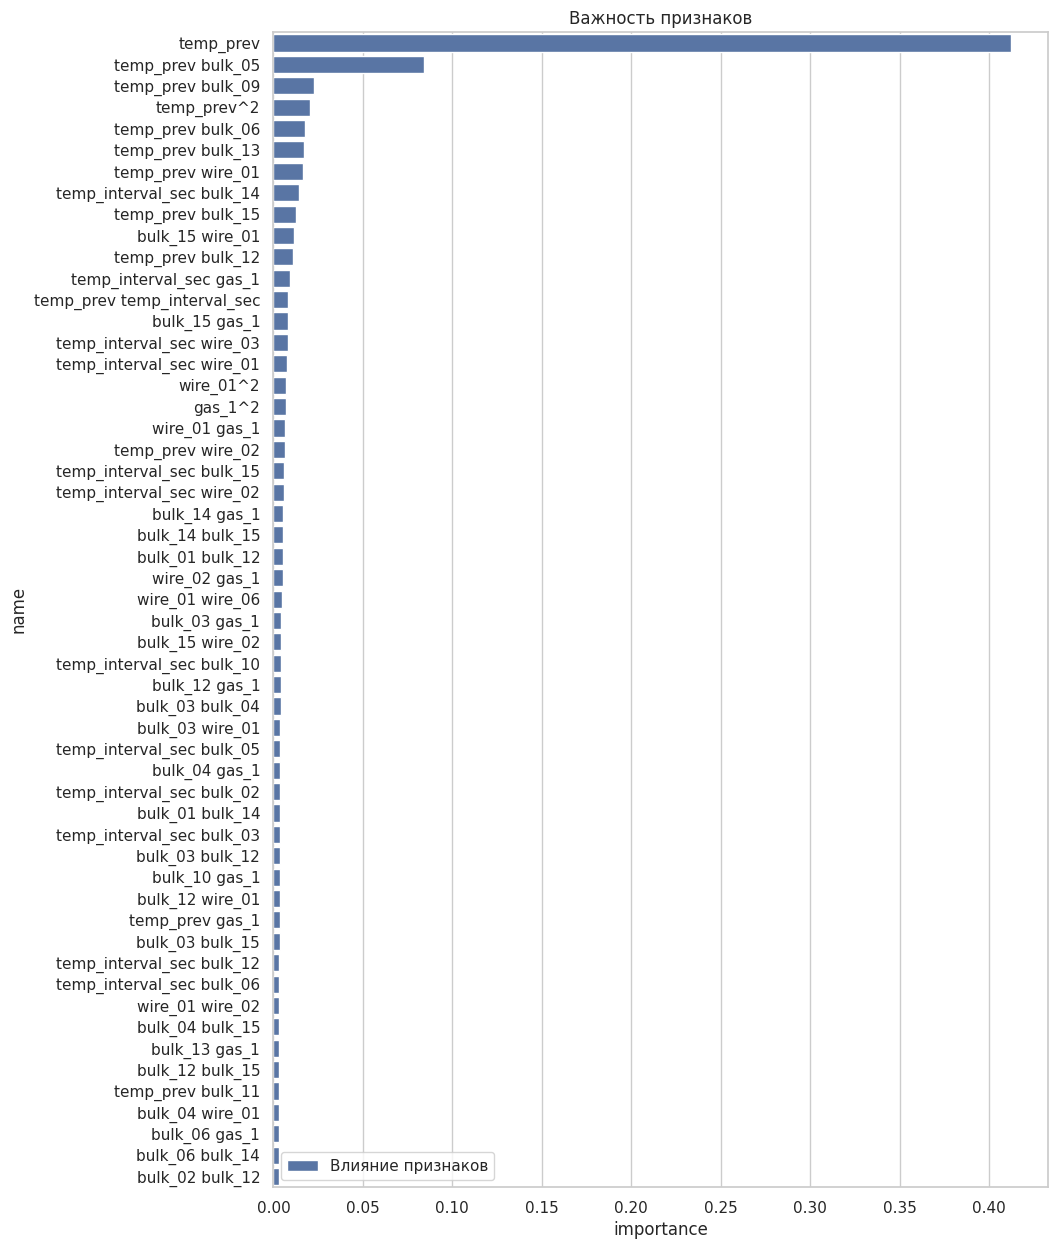

In [68]:
feature_importances.sort_values(by='importance', ascending=False)
fig, axs = plt.subplots(1, 1, figsize=(10, 15))
sns.barplot(
	data=feature_importances.query('importance > 0.003').sort_values(by='importance', ascending=False),
	x="importance", y="name", label="Влияние признаков", orient='h').set_title('Важность признаков');

- Предыдущая температура объяснимо оказывает самое сильное влиянние на результат
- Дальше идут нелинейные комбинацмм предыдущей температуры и различных добавок
- Кроме температуры линейных параметров среди самых важных не встретилось
- Очень странно, что нет нагрева - это как-то совсем не логично